# Integrasi Struktur Data untuk Pipeline Analisis Sederhana
**Mata Kuliah:** Struktur Data Bioinformatika (BIF1223) — Pertemuan #15
**Organisme:** *Hypsibius dujardini* (tardigrade / water bear)

Notebook ini mengimplementasikan pipeline analisis sekuens DNA: membaca sekuens FASTA,
menghitung frekuensi nukleotida, menghitung GC Content, mengurutkan & menampilkan sekuens
terbaik, visualisasi, dan ekspor ke CSV.

**Sumber data:** 9 sekuens *Hypsibius dujardini* diunduh dari NCBI Nucleotide
([ncbi.nlm.nih.gov/nuccore](https://www.ncbi.nlm.nih.gov/nuccore)), terdiri dari:
- 1 EST (Expressed Sequence Tag) — clone `Hd_mx17_69B08`, similar dengan gen *RecG*
  (ATP-dependent DNA helicase, accession **CF544295.1**)
- 4 sekuens gen **COX1** (cytochrome c oxidase subunit I, mitokondria) — accession
  **PQ356833.1 - PQ356836.1**
- 4 sekuens region **ITS** (Internal Transcribed Spacer, non-coding) — accession
  **PQ354674.1 - PQ354677.1**

> 📌 **Catatan taksonomi:** Sejak 2018, strain laboratorium yang umum disebut
> "*Hypsibius dujardini*" pada banyak studi genom sebenarnya telah diklasifikasi ulang
> sebagai spesies baru, *Hypsibius exemplaris*. Sekuens pada notebook ini diunduh dengan
> nama organisme *Hypsibius dujardini* sensu NCBI Taxonomy (taxid 232323).

In [ ]:
import csv
import matplotlib.pyplot as plt

## 1. Membaca File FASTA → Disimpan dalam **List**

Setiap record FASTA (header + sekuens) disimpan sebagai sebuah `dict`,
dan seluruh record dikumpulkan ke dalam satu **List** (`sequences`).

In [ ]:
def read_fasta(filepath):
    """Membaca file FASTA, mengembalikan List[dict] dengan key id/description/sequence."""
    sequences = []          # struktur data: List
    current_id, current_desc, current_seq = None, "", []

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if current_id is not None:
                    sequences.append({
                        "id": current_id,
                        "description": current_desc,
                        "sequence": "".join(current_seq).upper()
                    })
                header = line[1:].split(" ", 1)
                current_id = header[0]
                current_desc = header[1] if len(header) > 1 else ""
                current_seq = []
            else:
                current_seq.append(line)
        if current_id is not None:
            sequences.append({
                "id": current_id,
                "description": current_desc,
                "sequence": "".join(current_seq).upper()
            })
    return sequences


sequences = read_fasta("hypsibius_dujardini.fasta")
print(f"Jumlah sekuens terbaca: {len(sequences)}")
print("Daftar sekuens:")
for r in sequences:
    print(f"  - {r['id']:<14} | panjang={len(r['sequence']):<5} bp | {r['description'][:70]}")

Jumlah sekuens terbaca: 9
Daftar sekuens:
  - CF544295.1     | panjang=506   bp | Hd_mx17_69B08_T7 Hypsibius dujardini mixed stage (fraction 7) Hypsibiu
  - PQ356836.1     | panjang=640   bp | Hypsibius dujardini voucher Hyp.duj-26344 cytochrome c oxidase subunit
  - PQ356835.1     | panjang=640   bp | Hypsibius dujardini voucher Hyp.duj-18730-2 cytochrome c oxidase subun
  - PQ356834.1     | panjang=640   bp | Hypsibius dujardini voucher Hyp.duj-18730 cytochrome c oxidase subunit
  - PQ356833.1     | panjang=640   bp | Hypsibius dujardini voucher Hyp.duj-12147-2 cytochrome c oxidase subun
  - PQ354677.1     | panjang=476   bp | Hypsibius dujardini voucher Hyp.duj-41350 internal transcribed spacer 
  - PQ354676.1     | panjang=474   bp | Hypsibius dujardini voucher Hyp.duj-37250-2 internal transcribed space
  - PQ354675.1     | panjang=479   bp | Hypsibius dujardini voucher Hyp.duj-34294 internal transcribed spacer 
  - PQ354674.1     | panjang=474   bp | Hypsibius dujardini voucher Hy

## 2. Menghitung Frekuensi Nukleotida → Disimpan dalam **Dictionary**

Setiap sekuens dihitung jumlah basa A, T, G, C-nya menggunakan struktur **Dictionary (Hash Map)**,
di mana key = basa nukleotida dan value = jumlah kemunculannya.

In [ ]:
def nucleotide_frequency(sequence):
    """Menghitung frekuensi A/T/G/C dalam satu sekuens (struktur: Dictionary)."""
    freq = {"A": 0, "T": 0, "G": 0, "C": 0, "N": 0}
    for base in sequence:
        if base in freq:
            freq[base] += 1
        else:
            freq["N"] += 1  # basa ambigu selain A/T/G/C
    return freq


contoh_freq = nucleotide_frequency(sequences[0]["sequence"])
print(f"Contoh frekuensi nukleotida untuk '{sequences[0]['id']}':")
print(f"  {contoh_freq}")

Contoh frekuensi nukleotida untuk 'CF544295.1':
  {'A': 94, 'T': 65, 'G': 125, 'C': 155, 'N': 67}


## 3. Menghitung GC Content & Mengurutkan Sekuens

GC Content (%) = (jumlah G + jumlah C) / panjang sekuens × 100.
Seluruh sekuens kemudian diurutkan berdasarkan GC Content secara **menurun** (descending).

In [ ]:
def gc_content(freq, length):
    """Menghitung persentase GC Content dari dictionary frekuensi nukleotida."""
    if length == 0:
        return 0.0
    return (freq["G"] + freq["C"]) / length * 100


results = []  # List of dict: hasil gabungan id, panjang, frekuensi, dan GC%
for record in sequences:
    seq = record["sequence"]
    freq = nucleotide_frequency(seq)
    gc = gc_content(freq, len(seq))
    results.append({
        "id": record["id"],
        "description": record["description"],
        "length": len(seq),
        "freq": freq,
        "gc_content": round(gc, 2)
    })

results_sorted = sorted(results, key=lambda x: x["gc_content"], reverse=True)

print(f"{'No':<4}{'ID':<14}{'Panjang(bp)':<13}{'GC Content (%)':<16}")
print("-" * 47)
for i, r in enumerate(results_sorted, 1):
    print(f"{i:<4}{r['id']:<14}{r['length']:<13}{r['gc_content']:<16}")

No  ID            Panjang(bp)  GC Content (%)  
-----------------------------------------------
1   CF544295.1    506          55.34           
2   PQ354675.1    479          49.27           
3   PQ354674.1    474          49.16           
4   PQ354677.1    476          48.95           
5   PQ354676.1    474          48.95           
6   PQ356835.1    640          37.97           
7   PQ356834.1    640          37.97           
8   PQ356833.1    640          37.81           
9   PQ356836.1    640          37.34           


## 4. Menampilkan 3 Sekuens dengan GC Content Tertinggi

In [ ]:
top3 = results_sorted[:3]

print("3 Sekuens dengan GC Content tertinggi:\n")
for i, r in enumerate(top3, 1):
    print(f"#{i}  ID            : {r['id']}")
    print(f"    Deskripsi     : {r['description']}")
    print(f"    Panjang       : {r['length']} bp")
    print(f"    Frekuensi     : {r['freq']}")
    print(f"    GC Content    : {r['gc_content']}%\n")

3 Sekuens dengan GC Content tertinggi:

#1  ID            : CF544295.1
    Deskripsi     : Hd_mx17_69B08_T7 Hypsibius dujardini mixed stage (fraction 7) Hypsibius dujardini cDNA clone Hd_mx17_69B08 5' similar to Q88C73 (Q88C73) ATP-dependent DNA helicase RecG, mRNA sequence
    Panjang       : 506 bp
    Frekuensi     : {'A': 94, 'T': 65, 'G': 125, 'C': 155, 'N': 67}
    GC Content    : 55.34%

#2  ID            : PQ354675.1
    Deskripsi     : Hypsibius dujardini voucher Hyp.duj-34294 internal transcribed spacer region, partial sequence
    Panjang       : 479 bp
    Frekuensi     : {'A': 103, 'T': 140, 'G': 130, 'C': 106, 'N': 0}
    GC Content    : 49.27%

#3  ID            : PQ354674.1
    Deskripsi     : Hypsibius dujardini voucher Hyp.duj-33084-2 internal transcribed spacer region, partial sequence
    Panjang       : 474 bp
    Frekuensi     : {'A': 102, 'T': 139, 'G': 128, 'C': 105, 'N': 0}
    GC Content    : 49.16%



## 5. Visualisasi GC Content

Bar chart GC Content setiap sekuens, diurutkan dari tertinggi ke terendah.
Batang **merah** menandai 3 sekuens dengan GC Content tertinggi (top 3),
garis putus-putus menunjukkan rata-rata GC Content seluruh sekuens.

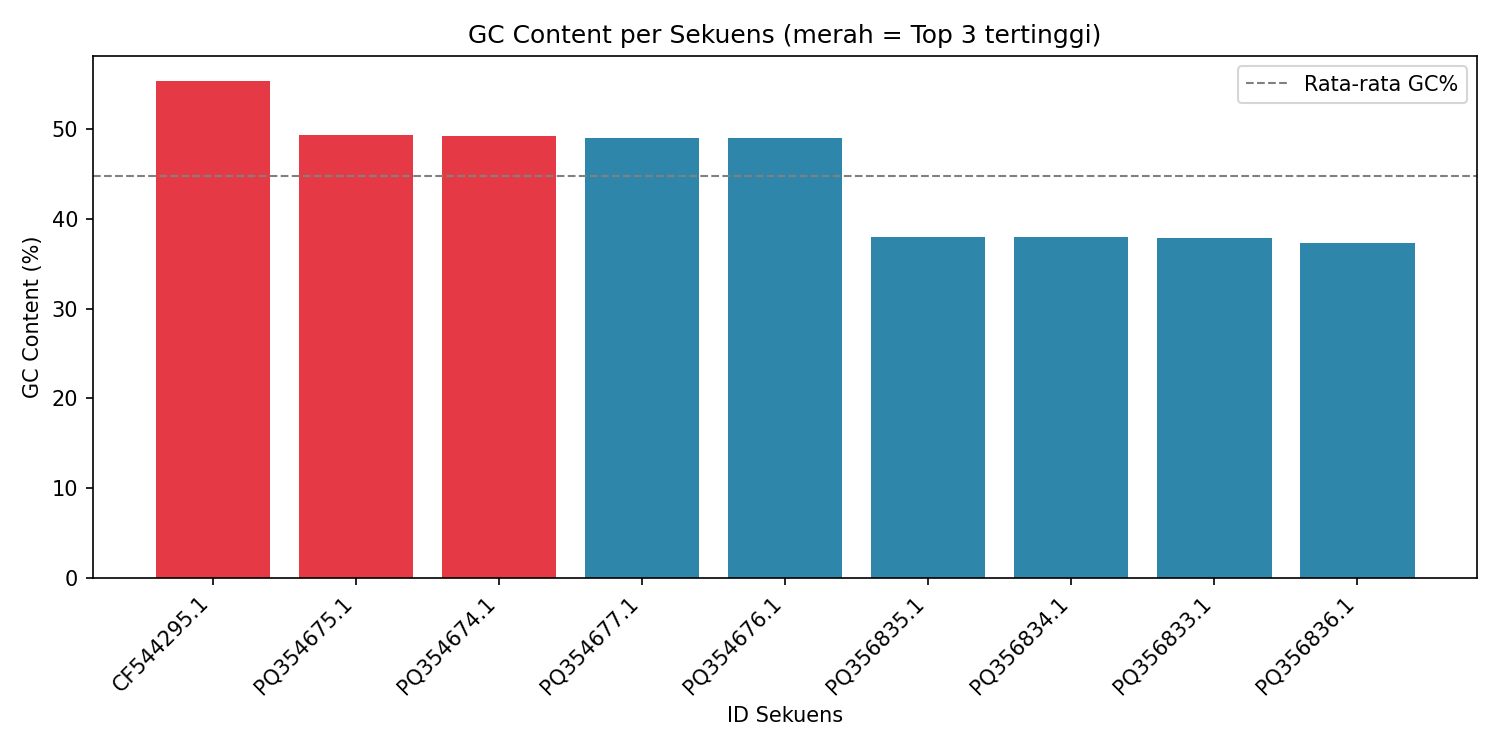

In [ ]:
ids = [r["id"] for r in results_sorted]
gc_values = [r["gc_content"] for r in results_sorted]
top3_ids = {r["id"] for r in top3}
colors = ["#E63946" if sid in top3_ids else "#2E86AB" for sid in ids]

plt.figure(figsize=(10, 5))
plt.bar(ids, gc_values, color=colors)
plt.axhline(y=sum(gc_values) / len(gc_values), color="gray", linestyle="--",
            linewidth=1, label="Rata-rata GC%")
plt.xlabel("ID Sekuens")
plt.ylabel("GC Content (%)")
plt.title("GC Content per Sekuens (merah = Top 3 tertinggi)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("gc_content_chart.png", dpi=150)
plt.show()

## 6. Menyimpan Hasil ke File CSV

In [ ]:
output_csv = "hasil_gc_content.csv"

with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Rank", "ID", "Deskripsi", "Panjang (bp)", "A", "T", "G", "C", "GC_Content (%)"])
    for rank, r in enumerate(results_sorted, 1):
        writer.writerow([
            rank, r["id"], r["description"], r["length"],
            r["freq"]["A"], r["freq"]["T"], r["freq"]["G"], r["freq"]["C"],
            r["gc_content"]
        ])

print(f"Hasil disimpan ke '{output_csv}'\n")
print("Preview isi CSV:")
with open(output_csv) as f:
    for line in f:
        print("  " + line.strip())

Hasil disimpan ke 'hasil_gc_content.csv'

Preview isi CSV:
  Rank,ID,Deskripsi,Panjang (bp),A,T,G,C,GC_Content (%)
  1,CF544295.1,"Hd_mx17_69B08_T7 Hypsibius dujardini mixed stage (fraction 7) Hypsibius dujardini cDNA clone Hd_mx17_69B08 5' similar to Q88C73 (Q88C73) ATP-dependent DNA helicase RecG, mRNA sequence",506,94,65,125,155,55.34
  2,PQ354675.1,"Hypsibius dujardini voucher Hyp.duj-34294 internal transcribed spacer region, partial sequence",479,103,140,130,106,49.27
  3,PQ354674.1,"Hypsibius dujardini voucher Hyp.duj-33084-2 internal transcribed spacer region, partial sequence",474,102,139,128,105,49.16
  4,PQ354677.1,"Hypsibius dujardini voucher Hyp.duj-41350 internal transcribed spacer region, partial sequence",476,102,141,128,105,48.95
  5,PQ354676.1,"Hypsibius dujardini voucher Hyp.duj-37250-2 internal transcribed spacer region, partial sequence",474,102,140,127,105,48.95
  6,PQ356835.1,"Hypsibius dujardini voucher Hyp.duj-18730-2 cytochrome c oxidase subunit I (COX1) gene, 

## Catatan & Insight Biologis

1. **Region non-coding cenderung lebih tinggi GC-nya dibanding gen coding mitokondria.**
   Pada hasil di atas, sekuens region **ITS** (non-coding, terletak di antara gen rRNA)
   menunjukkan GC Content yang lebih tinggi dibanding sekuens gen **COX1** (coding,
   mitokondria). Ini konsisten dengan pola umum: gen mitokondria hewan biasanya AT-rich,
   sedangkan region non-coding seperti ITS tidak terikat tekanan seleksi translasi sehingga
   komposisi basanya bisa berbeda.
2. **EST nuklir (gen RecG) memiliki GC Content tertinggi** di antara seluruh sekuens —
   masuk akal karena berasal dari genom inti (nuklir), bukan genom mitokondria, yang pada
   banyak organisme memang punya komposisi GC berbeda dari mtDNA.
3. **Catatan taksonomi:** Strain *H. dujardini* yang banyak digunakan untuk studi genom
   sebenarnya sejak 2018 sudah direklasifikasi sebagai *H. exemplaris* (Gąsiorek et al. 2018).
   Sekuens pada notebook ini diunduh dengan label *H. dujardini* sesuai NCBI Taxonomy,
   namun perbedaan nomenklatur ini penting dicatat saat menafsirkan hasil filogenetik/genomik.
4. Seluruh fungsi pipeline (`read_fasta`, `nucleotide_frequency`, `gc_content`) bersifat
   generik dan dapat dipakai ulang untuk dataset FASTA lain tanpa modifikasi.